In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data-2.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [77]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [78]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [79]:
grouped_df = df.groupby('Дата')['Количество'].count().reset_index(name='Количество_продаж')

Вывести несколько первых строк сгруппированных данных

In [80]:
print(grouped_df.head())

        Дата  Количество_продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

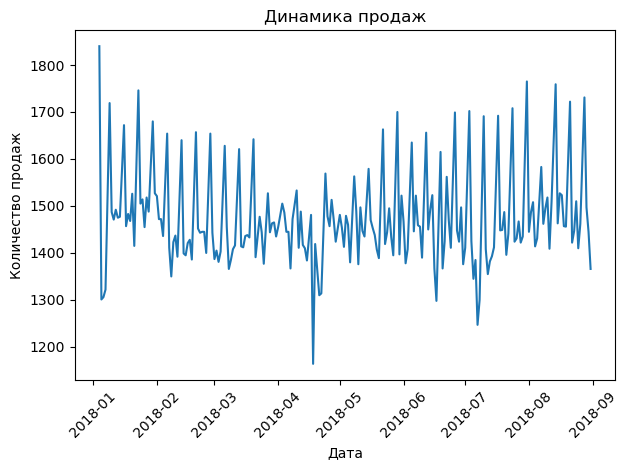

In [81]:
plt.figure()
plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'])

plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Динамика продаж')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [82]:
grouped_df[grouped_df['Количество_продаж'] == grouped_df['Количество_продаж'].max()]

,Дата,Количество_продаж
0,2018-01-04,1840


In [83]:
grouped_df[grouped_df['Количество_продаж'] == grouped_df['Количество_продаж'].min()]

,Дата,Количество_продаж
88,2018-04-18,1164


### На данном графике мы видим динамику продаж по месяцам. В целом, мы видим что количество продаж меняется из дня в день. 
### Вимим отсутствие полного стабильного поведения. На графике мы наблюдаем пики продаж, например в январе максимальные продажи. Видим периоды спадов продаж. По графику мы видим спады в апреле. 
### Колебания могут быть связаны сезонностью, возможно внешними событиями. 

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [84]:
mean = df['Количество'].mean()
std = df['Количество'].std()

df['z_score'] = (df['Количество'] - mean) / std

df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
z_score                    65.72326
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [85]:
df['Дата'] = pd.to_datetime(df['Дата'])

df_filtered = df[
    df['Дата'].dt.month.isin([6, 7, 8])]

df_filtered = df_filtered[
    df_filtered['Дата'].dt.dayofweek == 2]

df_filtered = df_filtered[
    df_filtered['Склад'].isin(df['Склад'].unique()[:3])]


top_product = (df_filtered.groupby('Номенклатура')['Количество'].sum().reset_index().sort_values('Количество', ascending=False).head(1))

top_product

,Номенклатура,Количество
1,product_1,8135


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [86]:
df_weather = pd.read_csv("weather_clean.csv", parse_dates=['datetime'])

In [87]:
print(df_weather.head())
print(df_weather.dtypes)

             datetime  temp
0 2018-08-31 23:00:00   8.2
1 2018-08-31 20:00:00   9.6
2 2018-08-31 17:00:00  11.3
3 2018-08-31 14:00:00  12.3
4 2018-08-31 11:00:00  13.2
datetime    datetime64[ns]
temp               float64
dtype: object


In [88]:
df_weather = df_weather.rename(columns={"datetime": "Дата","temp": "Температура"})

In [89]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])
temp_daily["Дата"] = pd.to_datetime(temp_daily["Дата"])

In [90]:
df_weather["Дата_день"] = df_weather["Дата"].dt.date

temp_daily = df_weather.groupby("Дата_день", as_index=False)["Температура"].mean()

temp_daily = temp_daily.rename(columns={"Дата_день": "Дата"})

In [91]:
print(grouped_df["Дата"].dtype)
print(temp_daily["Дата"].dtype)

datetime64[ns]
object


In [92]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])
temp_daily["Дата"] = pd.to_datetime(temp_daily["Дата"])

merged = grouped_df.merge(temp_daily, on="Дата", how="left")

In [93]:
merged = grouped_df.merge(temp_daily, on="Дата", how="left")

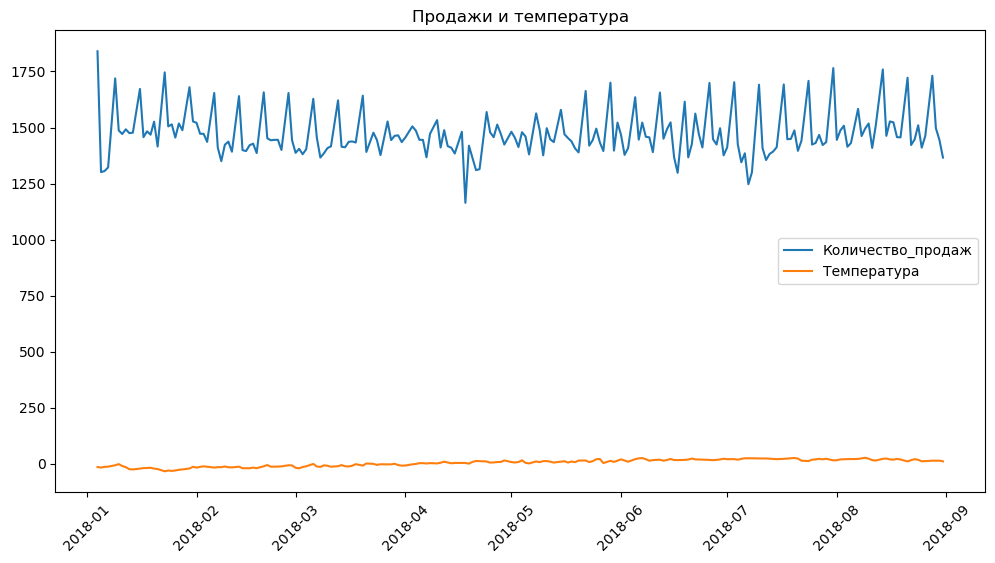

In [74]:
plt.figure(figsize=(12,6))

plt.plot(merged["Дата"], merged["Количество_продаж"], label="Количество_продаж")
plt.plot(merged["Дата"], merged["Температура"], label="Температура")

plt.legend()
plt.title("Продажи и температура")
plt.xticks(rotation=45)
plt.show()